# Import the necessary packages

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import pathlib 
import os
import scimap as sm
from utils.delaunay_graph import delaunay_adata_internal, delaunay_adata
from utils.cluster_stability import cluster_stability_calculate
from utils.celltype_enrichment_niche import nhood_enrichment
import anndata as ad

# Paths

In [65]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"

# Color palette

In [66]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

# Loading the required data

In [67]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata.h5ad"))

# Creating delaunay graphs for the ROIs

In [68]:
adata = delaunay_adata(adata, 
                       coords_key="spatial", 
                       phenotype="cell_category", 
                       image_id="patient_exp", 
                       label="spatial_count_delaunay")

## Get the confusion matrix of the neighbors

In [69]:
adata.uns["spatial_prop_delaunay"] = adata.uns["spatial_count_delaunay"].div(adata.uns["spatial_count_delaunay"].sum(axis=1), axis=0)

In [70]:
adata.uns["spatial_prop_delaunay"]

neighbour_phenotype,Actin+ cells,B cells,CD4+ T cells,CD8+ T cells,DCs,Endothelial cells,Granulocytes,Lymphatic endothelial cells,M1 macrophages,M1/M2 macrophages,M2 macrophages,MDSCs,Mast cells,NFC,NK cells,PCs,Treg T cells,Tumor cells,Epithelial cells
378930,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66114,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66113,0.111111,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.222222,0.0,0.0,0.0,0.666667,0.0
66112,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66111,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.142857,0.285714,0.000000,0.000000,0.0,0.142857,0.0,0.0,0.0,0.428571,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420571,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420572,0.000000,0.0,0.4,0.6,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
420573,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420564,0.000000,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


In [ ]:
best_k, best_score, results_df = cluster_stability_calculate(
    adata,
    uns_key="spatial_prop_delaunay",
    k_min=8,
    k_max=18,
    n_repeats=10,        
    sample_size=50000,      
    random_state=196979
)

k=8 | mean ARI=0.9608
k=9 | mean ARI=0.9175
k=10 | mean ARI=0.9442
k=11 | mean ARI=0.9646
k=12 | mean ARI=0.9654
k=13 | mean ARI=0.8720
k=14 | mean ARI=0.7272
k=15 | mean ARI=0.8711
k=16 | mean ARI=0.9021
k=17 | mean ARI=0.8265
k=18 | mean ARI=0.8638


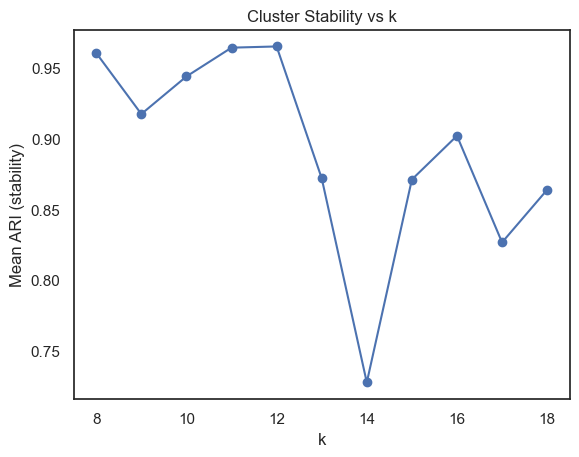

In [72]:
#showcase cluster stability analysis results
plt.figure()
plt.plot(results_df.index, results_df["mean_ARI"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean ARI (stability)")
plt.title("Cluster Stability vs k")
plt.show()

In [73]:
#save the results of cluster stability analysis
results_df.to_csv(os.path.join(data_dir, "cluster_stability_results.csv"), index=True)

## k = 12

In [74]:
adata = sm.tl.spatial_cluster(adata, 
                              df_name='spatial_prop_delaunay', 
                              method='kmeans', 
                              k=12, 
                              label='neigh_kmeans_count', 
                              random_state=196979)

Kmeans clustering


In [75]:
sm.pl.stacked_barplot(adata, 
                      x_axis='neigh_kmeans_count', 
                      y_axis='cell_category', 
                      plot_tool='plotly', 
                      color_discrete_map = full_palette)

In [76]:
#mix clustters 4 and 9 since they are similar in composition and define the clusters as follows:
cluster_to_name = {
    0: "Lymphatic_immune",
    1: "Tumor_bulk",
    2: "Tumor_NFC",
    3: "Stromal_fibroblasts",
    4: "Myeloid_granulocytic",
    5: "Epithelial_adjacent",
    6: "Vascular/Endothelial",
    7: "Lymphoid_B",
    8: "Lymphoid_enriched",
    9: "Tumor_myeloid",
    10: "Lymphoid_T",
    11:"Stromal_NFC"
}
#make neigh_kmeans integers first
adata.obs["neigh_kmeans_count"] = adata.obs["neigh_kmeans_count"].astype(int)
adata.obs["neighborhood"] = adata.obs["neigh_kmeans_count"].map(cluster_to_name)

In [77]:
nhood_enrichment(
    adata,
    group_key="cell_category",
    label_key="neighborhood",
    log=True,
    pvalues=True, 
)

100%|██████████| 200/200 [00:11<00:00, 17.08it/s]


In [78]:
adata.uns.keys()

odict_keys(['spatial_count_delaunay', 'spatial_prop_delaunay', 'neighborhood_cell_category_enrichment'])

In [79]:
enr = adata.uns["neighborhood_cell_category_enrichment"]["enrichment"]
pvalues = adata.uns["neighborhood_cell_category_enrichment"]["pvalue"]

## Save the enrichment and the pvalues

In [80]:
enr.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment.csv"), index=True)
pvalues.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"), index=True)

# Finally save the anndata with the neighborhoods

In [81]:
#save anndata
adata.write_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

## save the niches as niches_df for R

In [82]:
niches_df = adata.obs[["patient_ID", "patient_exp", "cell_category", "Cell Center X", "Cell Center Y", "survival_time_months", "neighborhood"]].copy()
niches_df.to_csv(os.path.join(data_dir, "niches_df.csv"), index=False)

In [47]:
adata_neighborhoods = sc.read_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

In [48]:
#keep in adata run == 141 and 145
adata_neighborhoods_subset = adata_neighborhoods[adata_neighborhoods.obs["run"].isin([141, 145])].copy()
#markers vector
markers = adata_neighborhoods_subset.var_names
#keep markers where not all values are NA
markers = [
    marker for marker in markers
    if not np.isnan(adata_neighborhoods_subset[:, marker].X.toarray()).any()
]

In [49]:
adata_neighborhoods_subset = adata_neighborhoods_subset[:, markers].copy()

adata_neighborhoods_subset.X = np.arcsinh(adata_neighborhoods_subset.X)

In [50]:
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_4"

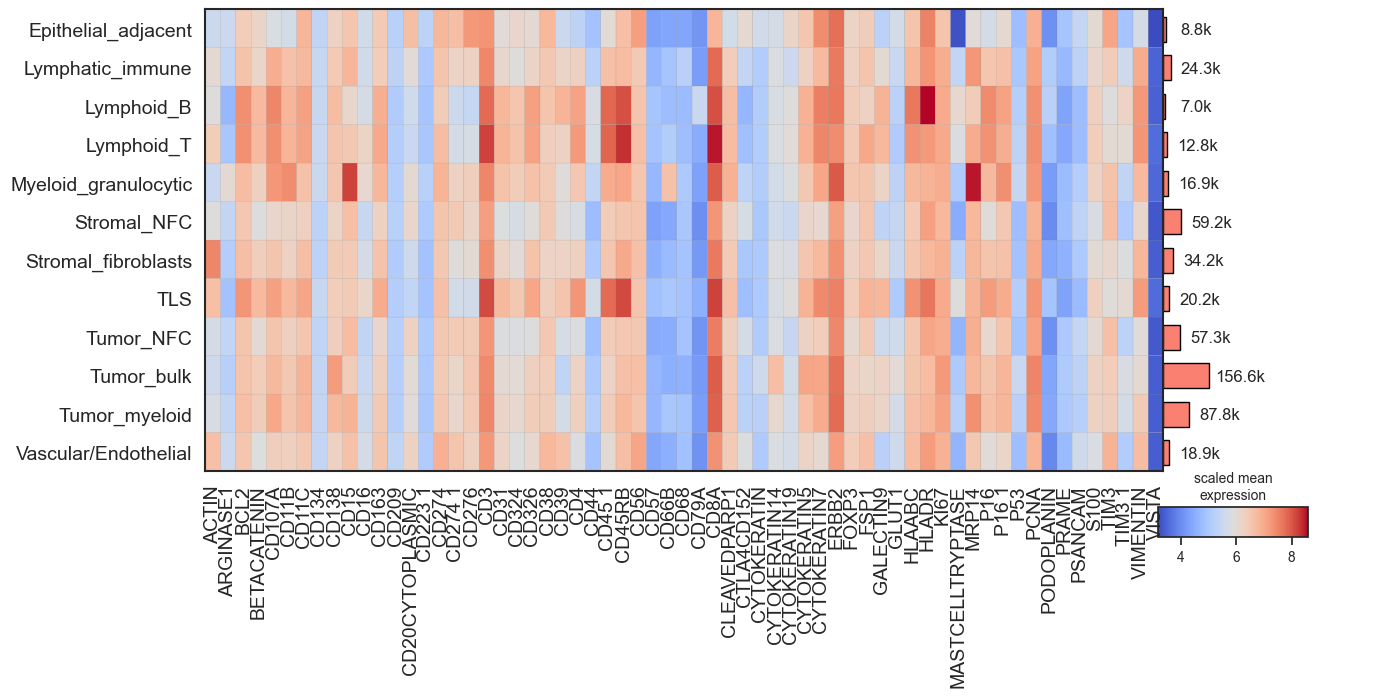

In [36]:
plot = sc.pl.matrixplot(adata_neighborhoods_subset, markers, groupby='neighborhood', 
                            cmap='coolwarm', 
                            use_raw=False, 
                            figsize=(15, 6), 
                            return_fig=True)
plot.add_totals()
axes = plot.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 12, current_pos[1]+4))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax.set_position([0.76, 0, 0.1, 0.05])
fig = axes['mainplot_ax'].figure
# fig.savefig(os.path.join(results_dir, 'stacked_violin.png'), 
#             dpi=300, 
#             bbox_inches='tight')